Resumen de resultados:


,Número de médicos,Tiempo medio de espera,Tiempo medio en el sistema,Espera máxima
0,2,3.342377,3.830489,6.680103
1,3,0.292026,0.768148,2.014810
2,4,0.221553,0.796625,1.956320


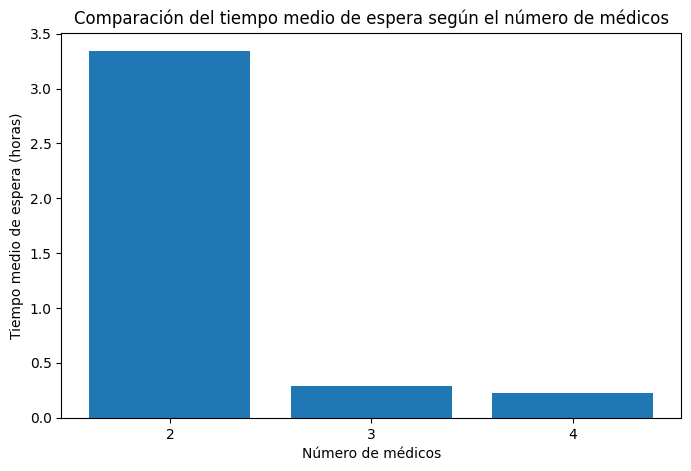

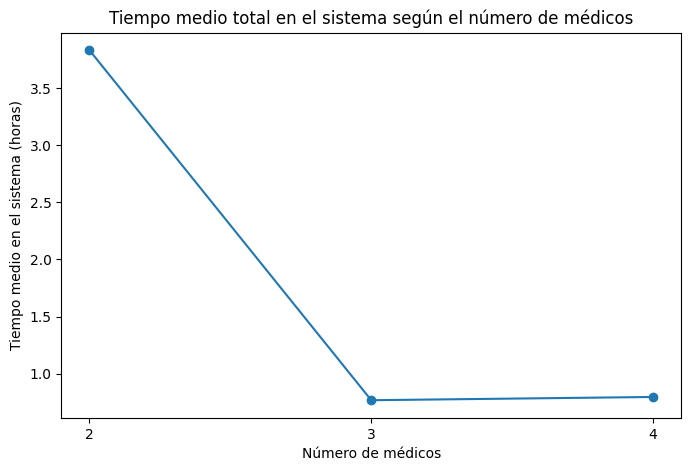

Primeros pacientes del escenario con 3 médicos:


,Paciente,Llegada,Inicio atención,Fin atención,Tiempo atención,Tiempo espera,Tiempo total en sistema,Médico asignado
0,1,0.037009,0.037009,0.417283,0.380274,0.000000,0.380274,1
1,2,0.102319,0.102319,0.128926,0.026607,0.000000,0.026607,2
2,3,0.141281,0.141281,0.346473,0.205192,0.000000,0.205192,3
3,4,0.159859,0.159859,0.232033,0.072175,0.000000,0.072175,2
4,5,0.185570,0.232033,0.264769,0.032736,0.046463,0.079200,2
5,6,0.309096,0.309096,2.609696,2.300601,0.000000,2.300601,2
6,7,0.355314,0.355314,0.549879,0.194565,0.000000,0.194565,3
7,8,0.445910,0.445910,1.275946,0.830035,0.000000,0.830035,1
8,9,0.585911,0.585911,0.732856,0.146944,0.000000,0.146944,3
9,10,0.820403,0.820403,1.392474,0.572071,0.000000,0.572071,3


In [ ]:

# 1. Librerías importadas
import numpy as np #sirve para trabajar con números, cálculos y datos aleatorios.
import pandas as pd #sirve para crear tablas.
import matplotlib.pyplot as plt #Sirve para hacer gráficos.


# 2. Parámetros generales


np.random.seed(42)  # Para que los resultados se puedan reproducir

num_pacientes = 100
tasa_llegada = 5      # λ: pacientes por hora
tasa_servicio = 2     # μ: pacientes que atiende un médico por hora

escenarios_medicos = [2, 3, 4] #cuántos médicos hay en cada caso


# 3. Función de simulación


def simular_hospital(num_medicos):
    """
    Simula una cola hospitalaria con varios médicos.
    Cada paciente llega de forma aleatoria y es atendido por el primer médico disponible.
    """

    # Tiempos entre llegadas de pacientes
    tiempos_entre_llegadas = np.random.exponential(1 / tasa_llegada, num_pacientes)

    # Hora de llegada acumulada de cada paciente
    tiempos_llegada = np.cumsum(tiempos_entre_llegadas)

    # Tiempos de atención de cada paciente
    tiempos_atencion = np.random.exponential(1 / tasa_servicio, num_pacientes)

    # Momento en el que cada médico queda libre
    medicos_disponibles = np.zeros(num_medicos)

    resultados = []

    for i in range(num_pacientes):
        llegada = tiempos_llegada[i]
        atencion = tiempos_atencion[i]

        # Elegimos el médico que antes queda disponible
        medico = np.argmin(medicos_disponibles)

        # El paciente empieza cuando llega o cuando el médico queda libre
        inicio_atencion = max(llegada, medicos_disponibles[medico])

        # Tiempo de espera
        espera = inicio_atencion - llegada

        # Fin de atención
        fin_atencion = inicio_atencion + atencion

        # Actualizamos disponibilidad del médico
        medicos_disponibles[medico] = fin_atencion

        resultados.append({
            "Paciente": i + 1,
            "Llegada": llegada,
            "Inicio atención": inicio_atencion,
            "Fin atención": fin_atencion,
            "Tiempo atención": atencion,
            "Tiempo espera": espera,
            "Tiempo total en sistema": fin_atencion - llegada,
            "Médico asignado": medico + 1
        })

    return pd.DataFrame(resultados)


# -----------------------------
# 3. Ejecutar escenarios
# -----------------------------

resumen = []

for medicos in escenarios_medicos:
    df = simular_hospital(medicos)

    tiempo_medio_espera = df["Tiempo espera"].mean()
    tiempo_medio_sistema = df["Tiempo total en sistema"].mean()
    espera_maxima = df["Tiempo espera"].max()

    resumen.append({
        "Número de médicos": medicos,
        "Tiempo medio de espera": tiempo_medio_espera,
        "Tiempo medio en el sistema": tiempo_medio_sistema,
        "Espera máxima": espera_maxima
    })

resumen_df = pd.DataFrame(resumen)

print("Resumen de resultados:")
display(resumen_df)


# -----------------------------
# 4. Gráfico: tiempo medio de espera
# -----------------------------

plt.figure(figsize=(8, 5))
plt.bar(resumen_df["Número de médicos"], resumen_df["Tiempo medio de espera"])
plt.xlabel("Número de médicos")
plt.ylabel("Tiempo medio de espera (horas)")
plt.title("Comparación del tiempo medio de espera según el número de médicos")
plt.xticks(escenarios_medicos)
plt.show()


# -----------------------------
# 5. Gráfico: tiempo medio en el sistema
# -----------------------------

plt.figure(figsize=(8, 5))
plt.plot(resumen_df["Número de médicos"], resumen_df["Tiempo medio en el sistema"], marker="o")
plt.xlabel("Número de médicos")
plt.ylabel("Tiempo medio en el sistema (horas)")
plt.title("Tiempo medio total en el sistema según el número de médicos")
plt.xticks(escenarios_medicos)
plt.show()


# -----------------------------
# 6. Tabla detallada de un escenario
# -----------------------------

df_3_medicos = simular_hospital(3)

print("Primeros pacientes del escenario con 3 médicos:")
display(df_3_medicos.head(10))
